### Описание системы
Рассматривается колл-центр, в который поступают звонки клиентов.  
Если в момент поступления звонка оператор свободен, звонок сразу принимается в обслуживание.  
Если оператор занят, звонок помещается в очередь ожидания.  
Очередь ограничена по длине и может содержать не более $m$ звонков.  
Если в момент поступления звонка очередь заполнена, звонок теряется.  
После завершения разговора оператор освобождается и принимает следующий звонок из очереди.

Система относится к классу M/M/1/m, где:

- поток входящих звонков является пуассоновским с интенсивностью $\lambda$;
- время обслуживания одного звонка имеет экспоненциальное распределение с параметром $\mu$;
- число операторов равно 1;
- длина очереди ограничена и равна $m$;
- дисциплина обслуживания - FIFO.

### Параметры модели

- $\lambda$ - интенсивность поступления звонков;
- $\mu$ - интенсивность обслуживания оператором;
- $m$ - максимальная длина очереди;
- $T$ - длительность моделирования;
- $N_{\text{runs}}$ - число независимых запусков модели.

### Основные формулы

#### Коэффициент загрузки системы
$$
\rho = \frac{\lambda}{\mu}
$$

Параметр $\rho$ показывает степень загрузки оператора.

#### Стационарные вероятности состояний
Пусть $K = m + 1$ — максимальное число звонков в системе с учетом обслуживаемого звонка.  
Тогда вероятности состояний определяются формулой:
$$
P_n = P_0 \rho^n, \quad n = 0,1,\dots,K
$$

где:
$$
P_0 = \frac{1-\rho}{1-\rho^{K+1}}, \quad \rho \ne 1
$$

при $\rho = 1$:
$$
P_0 = \frac{1}{K+1}
$$

#### Вероятность потери звонка
$$
P_{\text{loss}} = P_K
$$

#### Средняя длина очереди
$$
L_q = \sum_{n=0}^{K} \max(n-1, 0)\,P_n
$$

#### Среднее время ожидания звонка
$$
W_q = \frac{L_q}{\lambda_{\text{eff}}}
$$

где:
$$
\lambda_{\text{eff}} = \lambda(1 - P_{\text{loss}})
$$

#### Среднее время пребывания звонка в системе
$$
W = \frac{L}{\lambda_{\text{eff}}}
$$

где:
$$
L = \sum_{n=0}^{K} nP_n
$$

#### Вероятность простоя системы
$$
P_0
$$

#### Коэффициент загрузки системы
$$
1 - P_0
$$

### Алгоритм работы модели

1. Задаются параметры системы: интенсивность поступления звонков $\lambda$, интенсивность обслуживания $\mu$, длина очереди $m$, время моделирования $T$ и число запусков $N_{\text{runs}}$.
2. Для каждого запуска формируется поток входящих звонков с экспоненциальными интервалами между поступлениями.
3. Для каждого звонка определяется момент поступления в систему.
4. Если оператор свободен, звонок сразу поступает на обслуживание.
5. Если оператор занят, звонок помещается в очередь, если в ней есть место.
6. Если очередь заполнена, звонок теряется.
7. В ходе моделирования вычисляются:
   - вероятность потери звонка;
   - вероятность простоя системы;
   - средняя длина очереди;
   - среднее время ожидания;
   - среднее время пребывания звонка в системе;
   - коэффициент загрузки системы.
8. Моделирование повторяется многократно.
9. Итоговые характеристики определяются усреднением результатов по всем запускам.
10. Далее анализируется влияние длины очереди $m$ на эффективность работы колл-центра и определяется минимальное значение $m$, при котором вероятность потерь не превышает 5%.

In [13]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
lambda_calls = 8
mu_service = 10
queue_limit = 5
simulation_time = 1000
n_runs = 200
loss_threshold = 0.05

In [15]:
def simulate_call_center(lambda_calls, mu_service, queue_limit, simulation_time, random_state=None):
    rng = np.random.default_rng(random_state)

    next_arrival = rng.exponential(1 / lambda_calls)
    next_departure = np.inf

    queue = []
    current_call_arrival = None
    current_service_start = None

    waiting_times = []
    system_times = []

    total_calls = 0
    lost_calls = 0

    events = []
    last_time = 0.0
    queue_area = 0.0
    idle_time = 0.0
    busy_time = 0.0

    while next_arrival <= simulation_time or next_departure < np.inf:
        current_time = min(next_arrival, next_departure)

        if current_time == np.inf:
            break

        observed_time = min(current_time, simulation_time)

        if observed_time > last_time:
            queue_length = len(queue)
            busy_operator = 1 if current_call_arrival is not None else 0
            dt = observed_time - last_time

            queue_area += queue_length * dt
            busy_time += busy_operator * dt
            if busy_operator == 0:
                idle_time += dt

            last_time = observed_time

        if next_arrival <= next_departure and next_arrival <= simulation_time:
            current_time = next_arrival
            total_calls += 1

            if current_call_arrival is None:
                current_call_arrival = current_time
                current_service_start = current_time
                service_time = rng.exponential(1 / mu_service)
                next_departure = current_time + service_time
            elif len(queue) < queue_limit:
                queue.append(current_time)
            else:
                lost_calls += 1

            next_arrival = current_time + rng.exponential(1 / lambda_calls)

        else:
            current_time = next_departure

            waiting_times.append(current_service_start - current_call_arrival)
            system_times.append(current_time - current_call_arrival)

            if queue:
                current_call_arrival = queue.pop(0)
                current_service_start = current_time
                service_time = rng.exponential(1 / mu_service)
                next_departure = current_time + service_time
            else:
                current_call_arrival = None
                current_service_start = None
                next_departure = np.inf

    if last_time < simulation_time:
        queue_length = len(queue)
        busy_operator = 1 if current_call_arrival is not None else 0
        dt = simulation_time - last_time

        queue_area += queue_length * dt
        busy_time += busy_operator * dt
        if busy_operator == 0:
            idle_time += dt

    P_loss = lost_calls / total_calls if total_calls > 0 else 0.0
    P0 = idle_time / simulation_time
    Lq = queue_area / simulation_time
    Wq = np.mean(waiting_times) if waiting_times else 0.0
    W = np.mean(system_times) if system_times else 0.0
    rho_emp = busy_time / simulation_time

    return {
        "total_calls": total_calls,
        "lost_calls": lost_calls,
        "P_loss": P_loss,
        "P0": P0,
        "Lq": Lq,
        "Wq": Wq,
        "W": W,
        "rho_emp": rho_emp
    }

def theoretical_mmm_metrics(lambda_calls, mu_service, queue_limit):
    rho = lambda_calls / mu_service
    K = queue_limit + 1

    if abs(rho - 1.0) < 1e-12:
        P0 = 1 / (K + 1)
    else:
        P0 = (1 - rho) / (1 - rho ** (K + 1))

    probabilities = np.array([P0 * rho ** n for n in range(K + 1)])

    P_loss = probabilities[-1]
    lambda_eff = lambda_calls * (1 - P_loss)

    L = np.sum(np.arange(K + 1) * probabilities)
    Lq = np.sum(np.maximum(np.arange(K + 1) - 1, 0) * probabilities)

    Wq = Lq / lambda_eff if lambda_eff > 0 else 0.0
    W = L / lambda_eff if lambda_eff > 0 else 0.0
    rho_theory = 1 - P0

    return {
        "P0": P0,
        "P_loss": P_loss,
        "Lq": Lq,
        "Wq": Wq,
        "W": W,
        "rho": rho_theory,
        "L": L
    }

In [16]:
def run_multiple_simulations(lambda_calls, mu_service, queue_limit, simulation_time, n_runs):
    results = []

    for run in range(n_runs):
        result = simulate_call_center(
            lambda_calls=lambda_calls,
            mu_service=mu_service,
            queue_limit=queue_limit,
            simulation_time=simulation_time,
            random_state=run
        )
        results.append(result)

    df = pd.DataFrame(results)
    theory = theoretical_mmm_metrics(lambda_calls, mu_service, queue_limit)

    summary = pd.DataFrame({
        "Показатель": [
            "Общее число звонков",
            "Число потерянных звонков",
            "Вероятность потери",
            "Вероятность простоя",
            "Средняя длина очереди",
            "Среднее время ожидания",
            "Среднее время в системе",
            "Коэффициент загрузки"
        ],
        "Имитация": [
            df["total_calls"].mean(),
            df["lost_calls"].mean(),
            df["P_loss"].mean(),
            df["P0"].mean(),
            df["Lq"].mean(),
            df["Wq"].mean(),
            df["W"].mean(),
            df["rho_emp"].mean()
        ],
        "Теория": [
            lambda_calls * simulation_time,
            lambda_calls * simulation_time * theory["P_loss"],
            theory["P_loss"],
            theory["P0"],
            theory["Lq"],
            theory["Wq"],
            theory["W"],
            theory["rho"]
        ]
    })

    return df, summary, theory

In [17]:
runs_df, summary_df, theory_single = run_multiple_simulations(
    lambda_calls=lambda_calls,
    mu_service=mu_service,
    queue_limit=queue_limit,
    simulation_time=simulation_time,
    n_runs=n_runs
)

summary_df

,Показатель,Имитация,Теория
0,Общее число звонков,8001.495000,8000.000000
1,Число потерянных звонков,534.175000,530.733224
2,Вероятность потери,0.066728,0.066342
3,Вероятность простоя,0.253077,0.253073
4,Средняя длина очереди,1.399137,1.395507
5,Среднее время ожидания,0.187398,0.186833
6,Среднее время в системе,0.287453,0.286833
7,Коэффициент загрузки,0.746923,0.746927


In [18]:
runs_df.describe()

,total_calls,lost_calls,P_loss,P0,Lq,Wq,W,rho_emp
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,8001.495000,534.175000,0.066728,0.253077,1.399137,0.187398,0.287453,0.746923
std,88.880304,48.514665,0.005638,0.008957,0.050395,0.006517,0.007415,0.008957
min,7753.000000,417.000000,0.052645,0.228349,1.260923,0.168040,0.264808,0.718683
25%,7940.500000,502.000000,0.062962,0.246362,1.364539,0.183056,0.282458,0.740700
50%,7999.500000,532.000000,0.066507,0.252369,1.400622,0.187936,0.287854,0.747631
75%,8048.000000,568.250000,0.070721,0.259300,1.433827,0.191964,0.292389,0.753638
max,8246.000000,700.000000,0.085169,0.281317,1.550588,0.206690,0.308471,0.771651


In [ ]:
queue_range = range(0, 16)
queue_results = []

for m_val in queue_range:
    _, summary, theory = run_multiple_simulations(
        lambda_calls=lambda_calls,
        mu_service=mu_service,
        queue_limit=m_val,
        simulation_time=simulation_time,
        n_runs=n_runs
    )

    values = dict(zip(summary["Показатель"], summary["Имитация"]))
    queue_results.append({
        "m": m_val,
        "P_loss_sim": values["Вероятность потери"],
        "P_loss_theory": theory["P_loss"],
        "P0_sim": values["Вероятность простоя"],
        "P0_theory": theory["P0"],
        "Lq_sim": values["Средняя длина очереди"],
        "Lq_theory": theory["Lq"],
        "Wq_sim": values["Среднее время ожидания"],
        "Wq_theory": theory["Wq"],
        "W_sim": values["Среднее время в системе"],
        "W_theory": theory["W"],
        "rho_sim": values["Коэффициент загрузки"],
        "rho_theory": theory["rho"]
    })

df_queue = pd.DataFrame(queue_results)
df_queue

,m,P_loss_sim,P_loss_theory,P0_sim,P0_theory,Lq_sim,Lq_theory,Wq_sim,Wq_theory,W_sim,W_theory,rho_sim,rho_theory
0,0,0.444395,0.444444,0.555469,0.555556,0.000000,0.000000,0.000000,0.000000,0.100105,0.100000,0.444531,0.444444
1,1,0.262488,0.262295,0.409979,0.409836,0.262811,0.262295,0.044574,0.044444,0.144648,0.144444,0.590021,0.590164
2,2,0.173127,0.173442,0.338660,0.338753,0.562974,0.563686,0.085159,0.085246,0.185200,0.185246,0.661340,0.661247
3,3,0.121820,0.121847,0.298296,0.297477,0.859781,0.860543,0.122502,0.122493,0.222487,0.222493,0.701704,0.702523
4,4,0.088824,0.088819,0.271726,0.271056,1.138868,1.139388,0.156360,0.156307,0.256359,0.256307,0.728274,0.728944
5,5,0.066728,0.066342,0.253077,0.253073,1.399137,1.395507,0.187398,0.186833,0.287453,0.286833,0.746923,0.746927
6,6,0.050513,0.050399,0.240431,0.240319,1.626932,1.627567,0.214200,0.214243,0.314221,0.314243,0.759569,0.759681
7,7,0.038751,0.038756,0.230801,0.231005,1.838758,1.835782,0.239098,0.238725,0.339132,0.338725,0.769199,0.768995
8,8,0.030268,0.030073,0.224502,0.224058,2.022766,2.021156,0.260784,0.260478,0.360781,0.360478,0.775498,0.775942
9,9,0.023601,0.023493,0.218684,0.218794,2.189939,2.185109,0.280307,0.279710,0.380333,0.379710,0.781316,0.781206


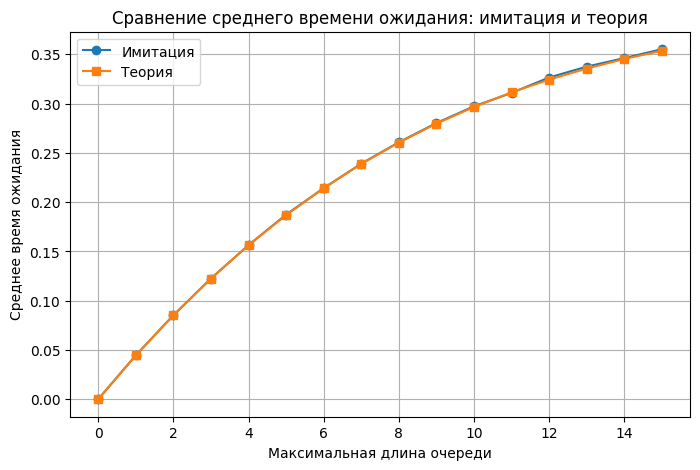

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(df_queue["m"], df_queue["Wq_sim"], marker="o", label="Имитация")
plt.plot(df_queue["m"], df_queue["Wq_theory"], marker="s", label="Теория")
plt.xlabel("Максимальная длина очереди")
plt.ylabel("Среднее время ожидания")
plt.title("Сравнение среднего времени ожидания: имитация и теория")
plt.grid(True)
plt.legend()
plt.show()

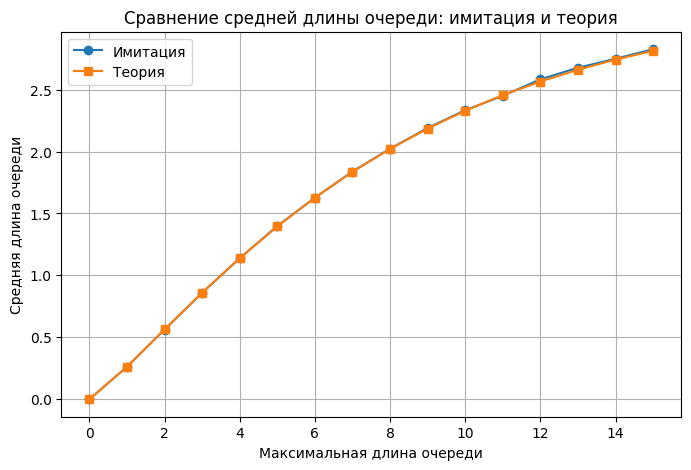

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(df_queue["m"], df_queue["Lq_sim"], marker="o", label="Имитация")
plt.plot(df_queue["m"], df_queue["Lq_theory"], marker="s", label="Теория")
plt.xlabel("Максимальная длина очереди")
plt.ylabel("Средняя длина очереди")
plt.title("Сравнение средней длины очереди: имитация и теория")
plt.grid(True)
plt.legend()
plt.show()

## Анализ влияния длины очереди

При увеличении максимально допустимой длины очереди уменьшается вероятность потери звонков, так как большее число клиентов может дождаться освобождения оператора.  
Одновременно с этим увеличиваются среднее время ожидания и средняя длина очереди.  
Это соответствует логике работы колл-центра: чем больше звонков система допускает в ожидание, тем меньше потерь, но тем дольше клиенты остаются в очереди.

In [22]:
optimal_rows = df_queue[df_queue["P_loss_theory"] <= loss_threshold]
optimal_m = int(optimal_rows.iloc[0]["m"])
optimal_m

7

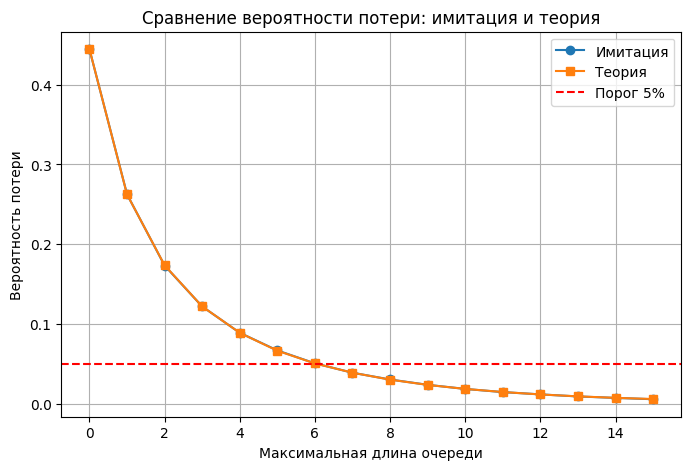

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(df_queue["m"], df_queue["P_loss_sim"], marker="o", label="Имитация")
plt.plot(df_queue["m"], df_queue["P_loss_theory"], marker="s", label="Теория")
plt.axhline(loss_threshold, color="red", linestyle="--", label="Порог 5%")
plt.xlabel("Максимальная длина очереди")
plt.ylabel("Вероятность потери")
plt.title("Сравнение вероятности потери: имитация и теория")
plt.grid(True)
plt.legend()
plt.show()

## Анализ вероятности потерь

При увеличении длины очереди вероятность потери звонков уменьшается, поскольку уменьшается число ситуаций, в которых поступивший звонок не может быть принят в систему.  
По графику и таблице можно определить минимальную длину очереди, при которой вероятность потерь не превышает заданный порог.  
Для рассматриваемых параметров системы это значение используется как оптимальная длина очереди.

## Выводы

В данной работе был смоделирован колл-центр как одноканальная система массового обслуживания с ограниченной очередью типа M/M/1/m.  
Входящий поток представлялся потоком звонков клиентов, а обслуживание выполнялось одним оператором.

В результате моделирования были определены следующие характеристики системы:

- вероятность потери звонка;
- вероятность простоя системы;
- средняя длина очереди;
- среднее время ожидания звонка;
- среднее время пребывания звонка в системе;
- коэффициент загрузки оператора.

По результатам анализа установлено:

1. При увеличении длины очереди уменьшается вероятность потери звонков.
2. При увеличении длины очереди возрастают средняя длина очереди и среднее время ожидания.
3. Теоретические и имитационные результаты близки друг к другу, что подтверждает корректность построенной модели.
4. Минимальная длина очереди, при которой вероятность потерь не превышает 5%, равна 7.

Следовательно, для эффективной работы колл-центра при заданных параметрах системы рекомендуется выбирать длину очереди не менее 7 звонков.